# Modular pipeline: PDB → density → ice → crowding → scattering → optics → detector

The other notebooks in `demo-notebooks/` (`create_particle_stack/`,
`create_micrograph/`, `create_tilt_series/`) all go through
`ImageGenerator`/`ImageGeneratorFromCoordinates`: one class that owns the
volume, wires up `PotentialBuilder`, `IceBank`/`RandomIcemaker`,
`CrowdWithDuplicates`, `Scattering`, `Aberration`, and `Detector`, and
drives them in the right order from `forward()`.

This notebook builds the **same physical pipeline by hand**, one stage per
section, calling each module directly instead of going through
`ImageGenerator`. The point is to show that SPECTER's forward-model pieces
are ordinary, independently-usable `torch.nn.Module`s — not APIs that only
work when wired together by the generator classes.

Pipeline (mirrors `ParticleGeneratorBase.process_volume` in
`imagegenerator/_generator.py`, stage for stage):

```
PDB file
  └─ atomic coordinates            (specter.pdb.PDB)
      └─ 3D scattering potential    (specter.potential.PotentialBuilder)
          └─ posed batch (rotate)   (specter.rotations.VolumeRotator)
              └─ + crowding         (specter.crowding.CrowdWithDuplicates)
                  └─ + amorphous ice (specter.ice: IceBank / RandomIcemaker)
                      └─ exit wave   (specter.scattering.Scattering)
                          └─ aberrated exit wave  (specter.aberrations.Aberration)
                              └─ detector image    (specter.microscope.Detector)
```

All parameters live in [`modular_pipeline.toml`](./modular_pipeline.toml),
loaded below via `load_config` — same TOML-driven convention as the other
demo notebooks. Edit that file, not this notebook, to change the structure,
box size, dose, defocus range, etc.


In [1]:
import logging

import matplotlib.pyplot as plt
import torch

import specter
from specter import rotations
from specter.config import load_config
from specter.image import normalize_particles
from specter.arrays import compute_nz, pad_volume
from specter.pdb import PDB
from specter.plots import plot3d
from specter.potential import PotentialBuilder
from specter.crowding import CrowdWithDuplicates
from specter.ice import blend_ice_into_volume, resolve_icemaker
from specter.scattering import Scattering
from specter.aberrations import (
    Aberration,
    defocus_midplane_shift,
)
from specter.microscope import Detector
from specter.rotations import Rotation, VolumeRotator

In [2]:
config = load_config("modular_pipeline.toml")

In [3]:
specter.set_verbosity(logging.INFO)
device = config.device
device

'cuda:0'

## 1. PDB → atomic coordinates

`specter.pdb.PDB` fetches (or loads a local) PDB/mmCIF structure and parses
it into atomic coordinates + atomic numbers — the raw input every
downstream stage needs. This step is identical to what
`ImageGeneratorFromCoordinates` does internally; it's already a
standalone, reusable object, no changes needed here.

In [4]:
pdb = PDB(config.pdb_code, assembly=config.assembly, savefolder=config.pdb_savefolder)
pdb.coordinates.shape, pdb.atomic_numbers.shape

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: /mnt/cbis/home/e0788253/czii/specter/pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

(torch.Size([46382, 3]), torch.Size([46382]))

## 2. Atomic coordinates → 3D scattering potential (density)

`PotentialBuilder` voxelizes the atomic coordinates onto a grid using a
parameterized atomic scattering potential (Kirkland by default) — this is
the "density" referenced in the title. It's a plain `nn.Module` that takes
coordinates and returns a volume; nothing about it depends on
`ImageGenerator`.

In [5]:
pb = PotentialBuilder(config.num_pixels, config.pixel_size, pdb.atomic_numbers)
with torch.no_grad():
    V0 = pb(pdb.coordinates).clone()

V0.shape

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

torch.Size([256, 256, 256])

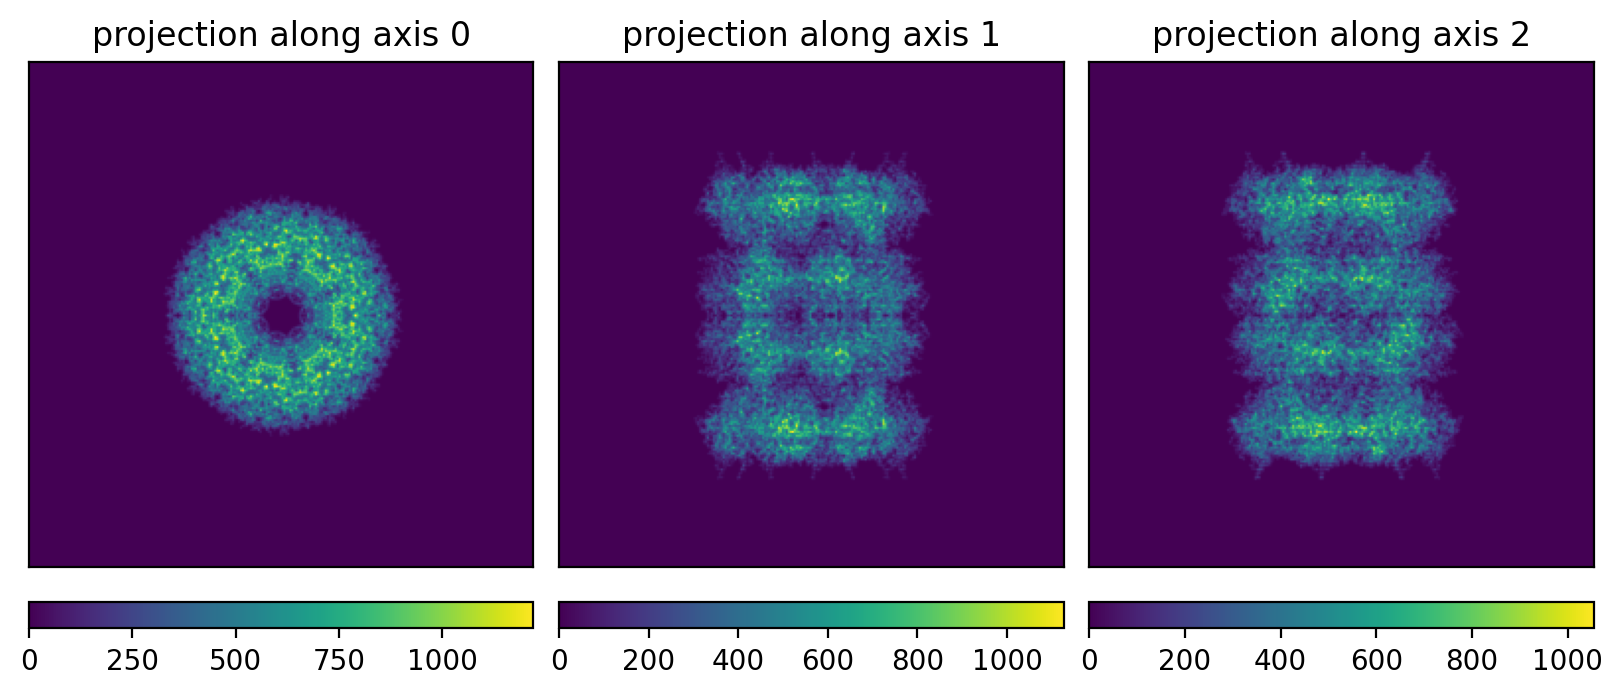

In [6]:
plot3d(V0)

## 3. Pose sampling & volume rotation

Everything from here on operates on a *batch* of particle images, each at
its own orientation/shift/defocus — so before touching ice, crowding, or
scattering we need a batch of rotated copies of the density volume built
above. `VolumeRotator` (used internally by `ImageGenerator`, the
pre-built-volume variant) does exactly this and is just as usable on its
own: build an affine matrix per pose from quaternions/translations via
`specter.rotations`, then call the rotator.

In [7]:
n_particles = config.n_particles

quaternions = rotations.random_quaternion(n_particles)

# random in-plane shift; set config.shift = 0.0 for no shifts
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * config.shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * config.shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)

nz, ny, nx = V0.shape
rotator = VolumeRotator(nz, ny, nx, origin="relion").to(device)

R = Rotation.from_quat(quaternions)
T = rotations.translations_angstrom_to_torch(
    translations, config.num_pixels, config.pixel_size
)
theta = rotations.build_affine_matrix(R.as_matrix(), T)

V = rotator(V0.to(device), theta.to(device))
V.shape

torch.Size([4, 256, 256, 256])

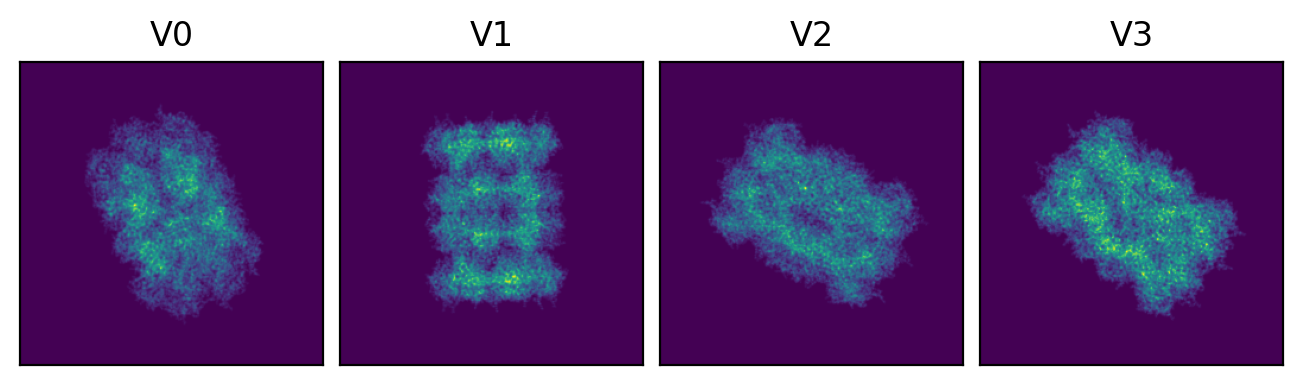

In [8]:
fig, axes = plt.subplots(1, 4, dpi=200, constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(V[i].sum(0).cpu())
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"V{i}")
plt.show()

## 4. Padding for FFT / multislice

`nz` may need to grow to accommodate an `ice_thickness` larger than the
particle box, and the XY box is optionally padded to suppress the circular
(wrap-around) convolution artifacts multislice would otherwise produce at
the box edges. `compute_nz`/`pad_volume` are the exact helper functions
`ImageGenerator` itself calls for this — plain tensor bookkeeping with no
simulation logic tied to the generator classes, so they live in
`specter.arrays` alongside SPECTER's other array utilities rather than
under `specter.imagegenerator`.

In [9]:
nz_padded = compute_nz(config.num_pixels, config.ice_thickness, config.pixel_size)
V = pad_volume(V, config.num_pixels, nz_padded, config.ice_thickness, config.pad_fft)

pad_nxy = (
    config.num_pixels + (config.num_pixels // 2) * 2
    if config.pad_fft
    else config.num_pixels
)
V.shape

torch.Size([4, 256, 512, 512])

## 5. Molecular crowding (optional)

`CrowdWithDuplicates` places extra Poisson-disk-sampled, randomly rotated
copies of the *same* structure around each particle, simulating a crowded
field of view. It's built once from the original (unrotated, unpadded)
density `V0`, then called once per batch item — mirroring exactly what
`ParticleGeneratorBase.process_volume` does, just spelled out here instead
of hidden inside it.

In [10]:
crowd_min_distance = (
    config.crowd_min_distance
    if config.crowd_min_distance is not None
    else pdb.max_diameter
)
crowd_max_distance_z = (
    config.crowd_max_distance_z
    if config.crowd_max_distance_z is not None
    else nz_padded * config.pixel_size
)

crowd = CrowdWithDuplicates(
    V0.to(device),
    config.pixel_size,
    crowd_min_distance,
    nxy_out=pad_nxy,
    nz_out=nz_padded,
    max_distance_z=crowd_max_distance_z,
    method="3d",
    n_points=torch.inf,
    seed="origin",
    chunk_size=1,
).to(device)

with torch.no_grad():
    for i in range(len(V)):
        V[i] = V[i] + crowd()

Rotating duplicates and insert into micrograph:   0%|          | 0/10 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/7 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/8 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/7 [00:00<?, ?it/s]

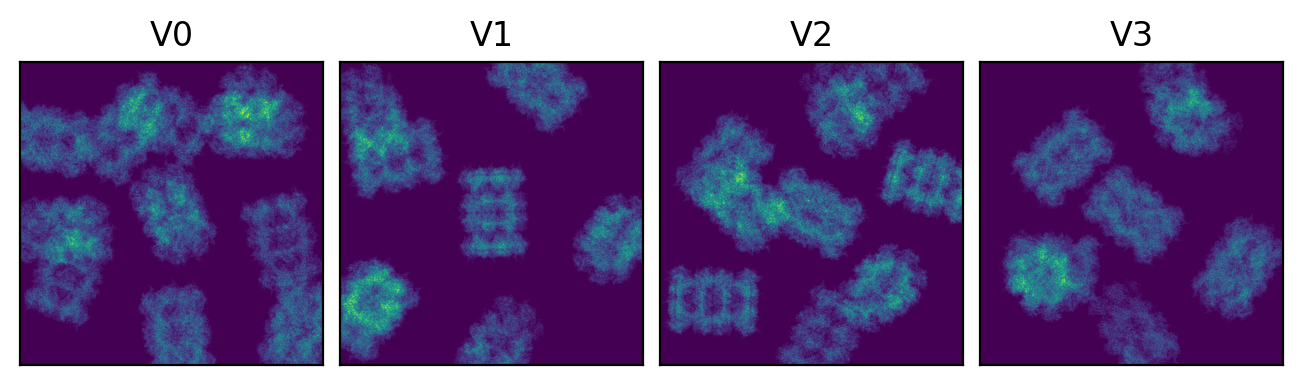

In [11]:
fig, axes = plt.subplots(1, 4, dpi=200, constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(V[i].sum(0).cpu())
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"V{i}")
plt.show()

## 6. Amorphous ice solvation

Ice is added only where the structure itself has little density — a
`gd`/`random` icemaker is built via `resolve_icemaker` (the same helper
`MicrographGenerator`/`TiltSeriesGenerator` use to turn an `ice_model`
string into a concrete `IceBank`/`RandomIcemaker`), and blended in with
`blend_ice_into_volume`, which masks and adds the ice for you. Both
functions live in `specter.ice` and have no dependency on `ImageGenerator`
at all — this is the one stage where a fully decoupled, reusable helper
already existed for the exact masking logic used internally.

In [12]:
icemaker = resolve_icemaker(
    config.ice_model,
    config.pixel_size,
    pad_nxy,
    nz_padded,
    ice_cache_dir=config.ice_cache_dir,
).to(device)

with torch.no_grad():
    V = blend_ice_into_volume(V, icemaker, config.pixel_size)

V.shape

Generating tiled ice volumes:   0%|          | 0/4 [00:00<?, ?it/s]

Placing ice tiles:   0%|          | 0/4 [00:00<?, ?it/s]

Placing ice tiles:   0%|          | 0/4 [00:00<?, ?it/s]

Placing ice tiles:   0%|          | 0/4 [00:00<?, ?it/s]

Placing ice tiles:   0%|          | 0/4 [00:00<?, ?it/s]

torch.Size([4, 256, 512, 512])

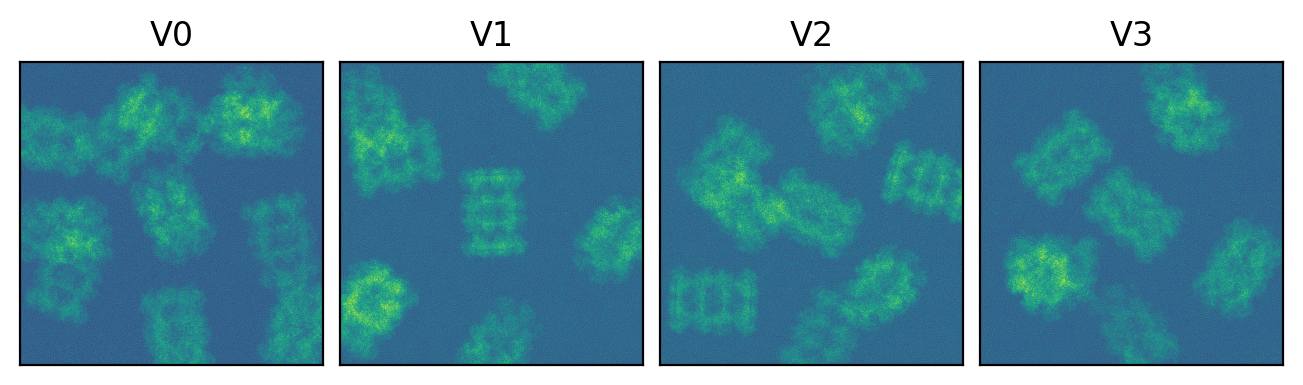

In [13]:
fig, axes = plt.subplots(1, 4, dpi=200, constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(V[i].sum(0).cpu())
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"V{i}")
plt.show()

## 7. Electron scattering (multislice)

`Scattering` propagates the complex electron wave through the 3D potential
and returns the 2D exit wave at the specimen's far face — a self-contained
module, parameterized only by box size, pixel size, and beam energy.

In [14]:
scattering = Scattering(
    pad_nxy,
    config.pixel_size,
    config.energy,
    scattering_model=config.scattering_model,
    nz=nz_padded,
    alpha=config.alpha,
    progressbars=False,
).to(device)

with torch.no_grad():
    exitwaves = scattering(V)

exitwaves.shape, exitwaves.dtype

(torch.Size([4, 512, 512]), torch.complex64)

## 8. Microscope optics / aberrations — the swappable stage

By default, `Aberration` applies defocus + Cs (+ any other transfer-function
terms present in `ctf_params`) in Fourier space. One wrinkle to know about:
multislice evaluates the exit wave at the volume's *mid-plane*, but CTF
defocus values (from CryoSPARC/RELION conventions) are measured from the
specimen's entry face — `ImageGenerator` corrects for this internally, and
`specter.aberrations.defocus_midplane_shift` is the public function it's
built on, so composing this by hand doesn't mean re-deriving the correction
yourself.

`bfactor` is the one CTF term that's also a constructor kwarg here, matching
`ImageGenerator`/`BaseImager`/`Reconstructor`: since it's usually one global
calibration value for a whole batch rather than something that genuinely
varies per particle (unlike `dfu`/`cs`), it gets the same "pass a scalar
here" convenience as `dose_per_angstrom`. If given, it overrides any
`"bfactor"` already in `ctf_params` — same override-wins precedence as
those other classes, so there's one rule to remember across the library,
not a different one per class.

In [15]:
Cs_A = config.cs * 1e7  # mm -> Å

defocus_A = (
    torch.rand(n_particles) * (config.defocus_max - config.defocus_min)
    + config.defocus_min
)
# multislice evaluates the CTF at the volume's midplane, not its entry face
defocus_shift_A = defocus_midplane_shift(nz_padded, config.pixel_size)
dfu = defocus_A - defocus_shift_A

ctf_params = {
    "cs": torch.full((n_particles,), Cs_A),
    "dfu": dfu,
}

aberration = Aberration(
    pad_nxy,
    config.pixel_size,
    config.energy,
    aberration_model=config.aberration_model,
    alpha=config.alpha,
    bfactor=config.bfactor,
).to(device)

ctf_params_gpu = {k: v.to(device) for k, v in ctf_params.items()}
with torch.no_grad():
    detector_waves = aberration(exitwaves, ctf_params_gpu)

detector_waves.shape

torch.Size([4, 512, 512])

## 9. Detector physics

`Detector` converts the (possibly aberrated) exit wave to an intensity
image, applying dose scaling, optional MTF, and Poisson noise. It only
needs the exit wave, dose, and coincidence radius — it has no idea whether
the wave came from `Aberration` or the hand-rolled version above.

In [16]:
dose_batch = torch.full((n_particles,), config.dose_min, device=device)
coincidence_radius = torch.full(
    (n_particles,), config.coincidence_radius_min, device=device
)

# dose-fractionated coincidence loss (coincidence_radius > 0) needs num_frames;
# fall back to one frame per unit dose, same convention as create_particle_stack.
num_frames = (
    config.num_frames if config.num_frames is not None else int(config.dose_min)
)

detector = Detector(
    config.pixel_size,
    aberration_model=config.aberration_model,
    noise_model=config.noise_model,
    mtf=None,  # config.detector_model == "none"; swap in specter.detectors.k3_300kv(...) etc. otherwise
    num_frames=num_frames,
).to(device)

with torch.no_grad():
    images = detector(
        detector_waves, dose_batch, coincidence_radius, nxy=config.num_pixels
    )

images.shape

torch.Size([4, 256, 256])

## 10. Visualize

Both stacks — the stock `Aberration` model and the hand-rolled custom
transfer function — went through identical density/ice/crowding/scattering
and the same `Detector` call. The only difference is the extra phase ramp
injected in section 8, visible here as fringes on top of the usual
defocus-driven contrast.

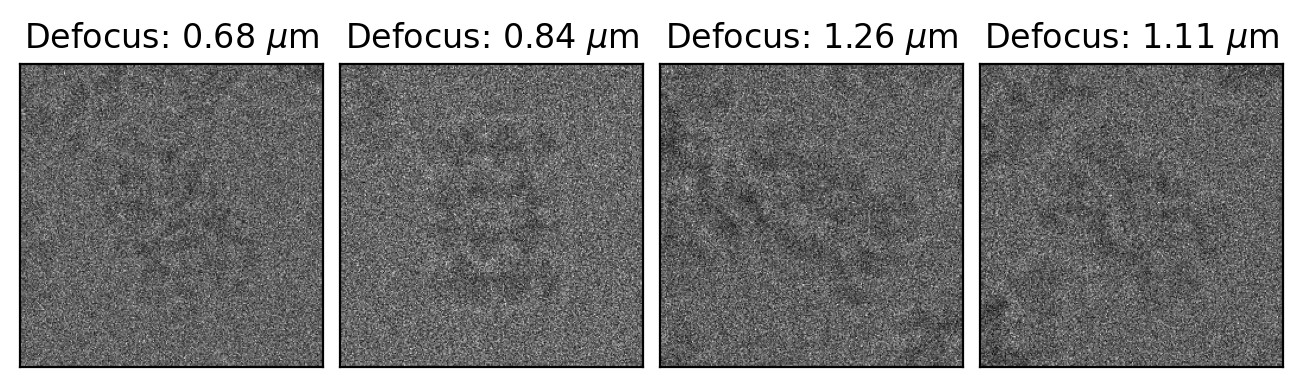

In [17]:
images_cpu = images.detach().cpu()

fig, axes = plt.subplots(1, n_particles, dpi=200, constrained_layout=True)
for i in range(n_particles):
    ax = axes[i]
    ax.imshow(images_cpu[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {defocus_A[i] / 10000:.2f} $\mu$m")

plt.show()

## 11. Normalize
Particles in cryo-EM are typically inverted (white particles on black background), mean-centered, and normalized to std = 1.

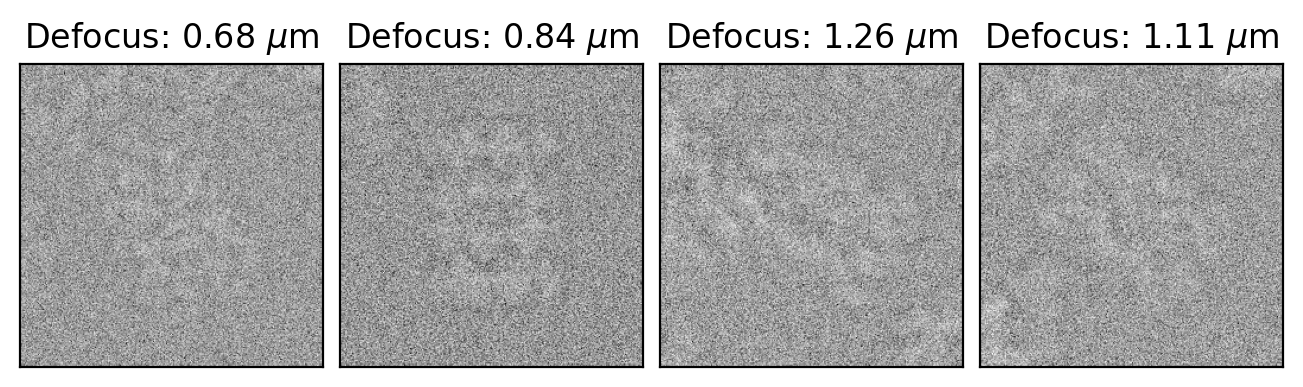

In [18]:
particles, means, stds = normalize_particles(images_cpu)
particles = -particles

fig, axes = plt.subplots(1, n_particles, dpi=200, constrained_layout=True)
for i, ax in enumerate(axes.ravel() if n_particles > 1 else [axes]):
    ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {defocus_A[i] / 10000:.2f} $\mu$m")
plt.show()